In [51]:
!ls /kaggle/input/datasets/vaspan/bccd-dataset

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [52]:
import shutil

src = "/kaggle/input/datasets/vaspan/bccd-dataset/data.yaml"
dst = "/kaggle/working/data.yaml"

shutil.copy(src, dst)

'/kaggle/working/data.yaml'

In [53]:
import yaml

yaml_path = "/kaggle/working/data.yaml"

with open(yaml_path) as f:
    data = yaml.safe_load(f)

# Update paths
data['train'] = '/kaggle/input/datasets/vaspan/bccd-dataset/train/images'
data['val']   = '/kaggle/input/datasets/vaspan/bccd-dataset/valid/images'

# Save
with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("YAML fixed ✅")

YAML fixed ✅


In [54]:
!git clone https://github.com/WongKinYiu/yolov9
%cd yolov9
!pip install -r requirements.txt

fatal: destination path 'yolov9' already exists and is not an empty directory.
/kaggle/working/yolov9/yolov9


In [55]:
!ls -l /kaggle/working

total 8
-rw-r--r--  1 root root  329 Mar 28 13:58 data.yaml
drwxr-xr-x 15 root root 4096 Mar 28 13:56 yolov9


In [56]:
!python train.py \
  --data /kaggle/working/data.yaml \
  --cfg models/detect/yolov9-c.yaml \
  --epochs 10 \
  --batch-size 8 \
  --img 640 \
  --device 0 \
  --workers 2 \
  --project /kaggle/working/runs/train \
  --name yolov9_exp \
  --exist-ok

2026-03-28 13:58:10.273467: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774706290.297769     580 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774706290.305470     580 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774706290.324827     580 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774706290.324856     580 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774706290.324860     580 computation_placer.cc:177] computation placer alr

In [57]:
import os
os.environ['WANDB_MODE'] = 'disabled'

os.chdir('/kaggle/working/yolov9')

!python train.py \
  --data /kaggle/working/data.yaml \
  --cfg models/detect/gelan-c.yaml \
  --epochs 3 \
  --batch-size 8 \
  --workers 0 \
  --noplots

2026-03-28 13:58:23.437773: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774706303.461597     602 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774706303.469209     602 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774706303.488947     602 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774706303.488975     602 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774706303.488979     602 computation_placer.cc:177] computation placer alr

In [58]:
!ls runs/train/exp

events.out.tfevents.1774705599.b4e06745f6e5.304.0  hyp.yaml  opt.yaml  weights


In [59]:
!ls runs/train/

exp  exp2  exp3  yolov9_pgi_bccd


In [60]:
!ls runs/train/exp

events.out.tfevents.1774705599.b4e06745f6e5.304.0  hyp.yaml  opt.yaml  weights


In [61]:
!ls runs/train/exp2/weights

In [62]:
import os
os.environ['WANDB_MODE'] = 'disabled'

os.chdir('/kaggle/working/yolov9')

!python train_dual.py \
  --data /kaggle/working/data.yaml \
  --cfg models/detect/yolov9-c.yaml \
  --epochs 3 \
  --batch-size 8 \
  --workers 0 \
  --noplots

2026-03-28 13:58:37.488551: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774706317.513036     628 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774706317.521075     628 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774706317.541617     628 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774706317.541650     628 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774706317.541653     628 computation_placer.cc:177] computation placer alr

In [63]:
!ls runs/train/

exp  exp2  exp3  exp4  yolov9_pgi_bccd


In [64]:
import os
os.chdir('/kaggle/working/yolov9')

# Check if the hyps folder exists
print(os.listdir('data/hyps/'))

['hyp.scratch-high.yaml']


In [65]:
!ls /kaggle/working

data.yaml  yolov9


In [66]:
import os, torch
os.environ['WANDB_MODE'] = 'disabled'
os.chdir('/kaggle/working/yolov9')

torch.serialization.add_safe_globals(['numpy._core.multiarray._reconstruct'])

!python train_dual.py \
  --data /kaggle/working/data.yaml \
  --cfg models/detect/yolov9-c.yaml \
  --epochs 50 \
  --batch-size 8 \
  --workers 0 \
  --device 0 \
  --noplots \
  --name yolov9_pgi_bccd

2026-03-28 14:00:43.829718: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774706443.854935     876 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774706443.862551     876 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774706443.882404     876 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774706443.882432     876 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774706443.882436     876 computation_placer.cc:177] computation placer alr

In [70]:
!find /kaggle/working -name "best.pt"

/kaggle/working/yolov9/runs/train/yolov9_pgi_bccd2/weights/best.pt
/kaggle/working/yolov9/runs/train/exp4/weights/best.pt


In [73]:
# Find best model automatically
import glob

weights_path = glob.glob('/kaggle/working/yolov9/runs/train/*/weights/best.pt')[-1]
print("Using weights:", weights_path)

# Run validation
!python val.py \
  --weights {weights_path} \
  --data /kaggle/working/data.yaml \
  --img 640 \
  --device 0

Using weights: /kaggle/working/yolov9/runs/train/exp4/weights/best.pt
val: data=/kaggle/working/data.yaml, weights=['/kaggle/working/yolov9/runs/train/exp4/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.7, max_det=300, task=val, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False, min_items=0
YOLO 🚀 v0.1-104-g5b1ea9a Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Traceback (most recent call last):
  File "/kaggle/working/yolov9/val.py", line 389, in <module>
    main(opt)
  File "/kaggle/working/yolov9/val.py", line 362, in main
    run(**vars(opt))
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py", line 124, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/yolov9/val.py", line 122, in run
    model = Detect

In [74]:
import pandas as pd
import glob

# Automatically find results.csv
csv_files = glob.glob('/kaggle/working/yolov9/runs/train/*/results.csv')

print("Found CSVs:", csv_files)

# Pick latest one
csv_path = csv_files[-1]
print("Using:", csv_path)

df = pd.read_csv(csv_path)
print(df.columns)
df.head()

Found CSVs: ['/kaggle/working/yolov9/runs/train/yolov9_pgi_bccd2/results.csv', '/kaggle/working/yolov9/runs/train/exp4/results.csv']
Using: /kaggle/working/yolov9/runs/train/exp4/results.csv
Index(['               epoch', '      train/box_loss', '      train/cls_loss',
       '      train/dfl_loss', '   metrics/precision', '      metrics/recall',
       '     metrics/mAP_0.5', 'metrics/mAP_0.5:0.95', '        val/box_loss',
       '        val/cls_loss', '        val/dfl_loss', '               x/lr0',
       '               x/lr1', '               x/lr2'],
      dtype='object')


,epoch,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95,val/box_loss,val/cls_loss,val/dfl_loss,x/lr0,x/lr1,x/lr2
0,0,4.6144,5.1798,5.3395,0.001073,0.199070,0.000918,0.000288,0,0,0,0.072100,0.003100,0.003100
1,1,4.5096,5.0831,5.3312,0.001929,0.092542,0.003929,0.001039,0,0,0,0.041221,0.004221,0.004221
2,2,4.6002,4.9793,5.3063,0.001744,0.058761,0.001196,0.000248,0,0,0,0.008230,0.003230,0.003230


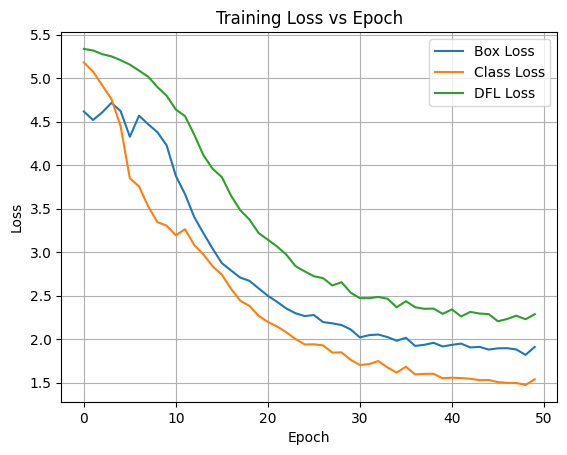

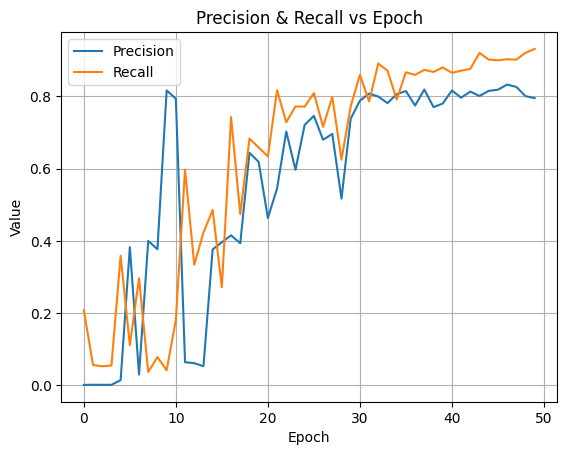

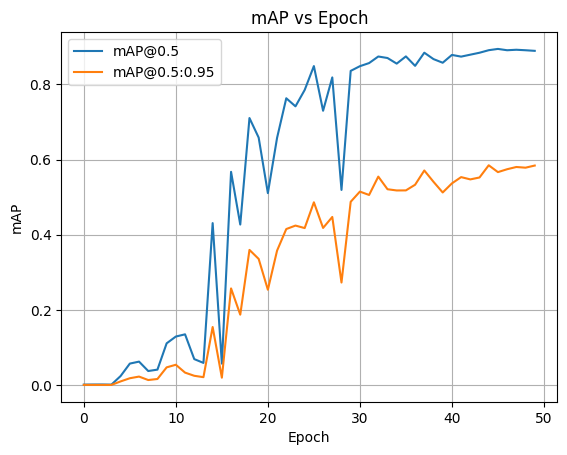

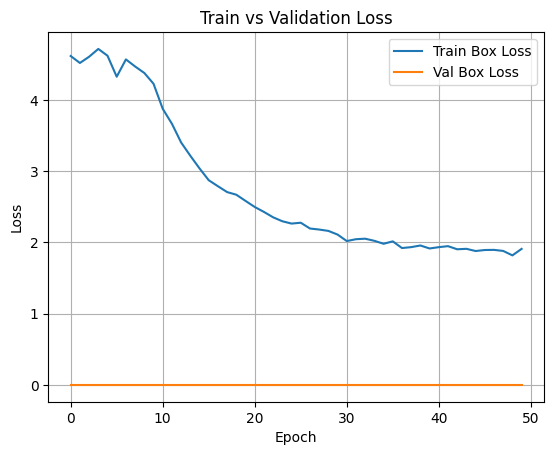

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/working/yolov9/runs/train/yolov9_pgi_bccd2/results.csv')

# 🔥 FIX column names
df.columns = df.columns.str.strip()

# -----------------------------
# 1. LOSS CURVES
# -----------------------------
plt.figure()
plt.plot(df['train/box_loss'], label='Box Loss')
plt.plot(df['train/cls_loss'], label='Class Loss')
plt.plot(df['train/dfl_loss'], label='DFL Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Epoch')
plt.legend()
plt.grid()
plt.show()


# -----------------------------
# 2. PRECISION & RECALL
# -----------------------------
plt.figure()
plt.plot(df['metrics/precision'], label='Precision')
plt.plot(df['metrics/recall'], label='Recall')

plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Precision & Recall vs Epoch')
plt.legend()
plt.grid()
plt.show()


# -----------------------------
# 3. mAP CURVES
# -----------------------------
plt.figure()
plt.plot(df['metrics/mAP_0.5'], label='mAP@0.5')
plt.plot(df['metrics/mAP_0.5:0.95'], label='mAP@0.5:0.95')

plt.xlabel('Epoch')
plt.ylabel('mAP')
plt.title('mAP vs Epoch')
plt.legend()
plt.grid()
plt.show()


# -----------------------------
# 4. TRAIN vs VAL LOSS (VERY IMPORTANT)
# -----------------------------
plt.figure()
plt.plot(df['train/box_loss'], label='Train Box Loss')
plt.plot(df['val/box_loss'], label='Val Box Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid()
plt.show()


In [78]:
import shutil

src = "/kaggle/working/yolov9/runs/train/yolov9_pgi_bccd2/weights/best.pt"
dst = "/kaggle/working/best_model.pt"

shutil.copy(src, dst)

print("Model copied to:", dst)

Model copied to: /kaggle/working/best_model.pt
